# Desarrollo de Modelos de Clasificación
En esta sección se desarrollarán los modelos de predicción propuestos para la investigación. Dado que se trata de un problema de clasificación, se implementarán varios modelos adicionales al modelo original, con el objetivo de comparar su desempeño.

Los modelos de clasificación seleccionados, que incorporan algoritmos de optimización para mejorar su rendimiento, son los siguientes:

 - KNN → KD-Trees, Ball Trees.
 - Naive Bayes → partial_fit() para entrenamiento por lotes.
 - XGBoost → tree_method='hist' y early_stopping_rounds.
 - SVM → SGD SVM (SGDClassifier) , LinearSVC en vez de SVC(kernel='linear'), RBF con Random Fourier Features

En las siguientes líneas de código se presenta el desarrollo e implementación de los modelos de clasificación seleccionados para esta investigación.

In [59]:
import pandas as pd
df = pd.read_csv("metricas_camiones.csv")

Cargamos los datos Pre-procesados para el desarrollo de los modelos.

## Modelo KNN

En las siguientes lineas de codigos, aplicaremos los modelos KD-Trees, Ball Trees.

Las librerias utilizadas para el **modelo de KNN** y para el desarrollo de modelos se encuentran a continuacion.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score,train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter, defaultdict
import time
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, accuracy_score, precision_score, roc_auc_score
import warnings

# Ignorar todos los FutureWarning y UserWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


##### Definición del modelo e hiperparámetros

En el siguiente código se define el dataset, estableciendo la variable de respuesta Y y las variables predictoras *X*. A continuación, se configura el modelo junto con el escalamiento de las variables predictoras dentro de un Pipeline. También se define la rejilla de búsqueda (*param_grid*) para los hiperparámetros del modelo.

Adicionalmente, se establece el método de validación cruzada (*Cross-Validation*) que será utilizado tanto en los bucles internos (inner) como externos (outer) del Nested Cross-Validation. En este caso, se empleará *StratifiedKFold*, debido a que la variable de respuesta es binaria, y este método asegura una distribución equilibrada de clases en cada partición.

In [61]:
# Definir variables predictoras y objetivo
X = df.drop(columns=["Equipo", "Suspension", "Falla"])  # Ajusta según tus datos
y = df["Falla"]

# 1) Divide en train_inner y test_externo (por ejemplo 80/20)
X_train_inner, X_test_ext, y_train_inner, y_test_ext = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "kneighborsclassifier__n_neighbors": [3, 4, 5, 6, 7,8,9],
    "kneighborsclassifier__weights": ["distance"],
    "kneighborsclassifier__metric": ["euclidean"],
    "kneighborsclassifier__algorithm": ["ball_tree", "kd_tree"]
}

# Definir Nested Cross-Validation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


Se realiza una validación cruzada anidada. En cada fold externo, se divide el dataset en entrenamiento y prueba. Al conjunto de entrenamiento se le aplica SMOTE para balancear las clases. Luego, se usa GridSearchCV con validación interna para encontrar los mejores hiperparámetros. El modelo optimizado se evalúa en el conjunto de prueba y se guardan predicciones, probabilidades, puntuaciones y los hiperparámetros seleccionados.

In [62]:
# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res) 

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
         # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["kneighborsclassifier__algorithm"]
        algorithm_times[algorithm].append(mean_time)

⏳ Tiempo total del fold 1: 1.78 segundos
⏳ Tiempo total del fold 2: 0.15 segundos
⏳ Tiempo total del fold 3: 0.12 segundos
⏳ Tiempo total del fold 4: 0.05 segundos
⏳ Tiempo total del fold 5: 0.06 segundos


Se obtienen los tiempos de procesamiento de cada *Outer loop*

#### Desbalanceo de datos - SMOTE
Dado que el conjunto de datos presenta un desbalance en las clases, en el siguiente código se aplica la técnica **SMOTE** *(Synthetic Minority Over-sampling Technique)* sobre los datos de entrenamiento. Esta técnica genera nuevas muestras sintéticas de la clase minoritaria, con el objetivo de equilibrar la distribución de clases y mejorar el rendimiento del modelo durante el entrenamiento.

In [63]:
# Verificar distribución antes de SMOTE
print("Distribución antes de SMOTE:")
print(y_train.value_counts())

# Verificar distribución después de SMOTE
print("\nDistribución después de SMOTE:")
print(y_train_res.value_counts())

Distribución antes de SMOTE:
Falla
1    7
0    6
Name: count, dtype: int64

Distribución después de SMOTE:
Falla
1    7
0    7
Name: count, dtype: int64


En este código se presentan los resultados del modelo utilizando los mejores hiperparámetros encontrados durante el proceso de entrenamiento.

In [64]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("kneighborsclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'ball_tree': 0.0027 segundos (promedio en 35 ejecuciones)
🔧 'kd_tree': 0.0024 segundos (promedio en 35 ejecuciones)
Mejores hiperparámetros globales: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance', 'algorithm': 'ball_tree'}


Se observa que el mejor tiempo de procesamiento fue obtenido por el algoritmo *KD Tree*. Sin embargo, el mejor desempeño en las métricas de evaluación fue alcanzado por el algoritmo *Ball Tree*.

#### Matriz de Confusión y Métricas de Desempeño
En el siguiente código se evalúa el desempeño del modelo a lo largo de cada fold externo del **Nested Cross-Validation**. Para esta validación, se seleccionaron 5 pliegues para el K-Fold externo y 3 pliegues para el K-Fold interno.

La matriz de confusión y las métricas calculadas provienen de los resultados obtenidos en el conjunto de prueba de cada uno de los folds externos. Además, se incluye la *curva ROC* y el valor del *AUC*, lo que permite una evaluación más completa del rendimiento del modelo.

A continuación, se presenta el código correspondiente a la generación de la matriz de confusión.

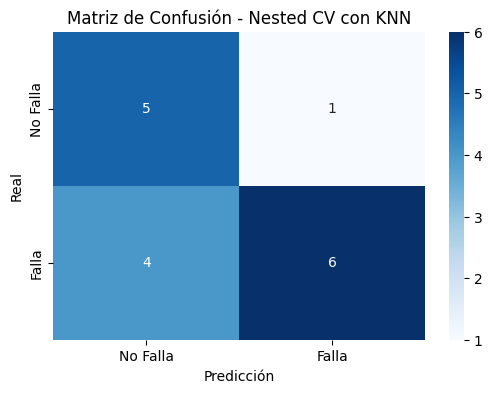

In [65]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con KNN")
plt.show()


En el siguiente bloque se presentan los valores correspondientes a las métricas de desempeño del modelo. Para los fines de esta investigación, la métrica principal utilizada para evaluar cada uno de los modelos será el Recall, debido a su relevancia en el contexto del problema planteado.

In [66]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.6666666666666666, 0.7777777777777777, 0.6666666666666666, 0.38888888888888884, 0.611111111111111]
Mean Accuracy: 0.6222 ± 0.1286
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.86      0.60      0.71        10

    accuracy                           0.69        16
   macro avg       0.71      0.72      0.69        16
weighted avg       0.74      0.69      0.69        16



#### Curva ROC y Métrica AUC

A continuación, se presenta la curva ROC y el valor de AUC obtenidos a lo largo del proceso de Nested Cross-Validation. Esta visualización permite evaluar la capacidad del modelo para discriminar entre clases, considerando todos los umbrales de decisión posibles.

AUC Score: 0.7750


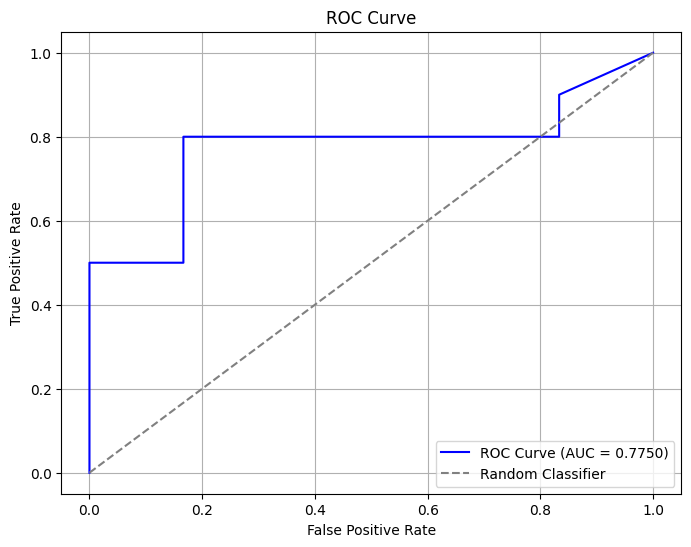

In [67]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

En el código anterior completo, se muestra la implementación del modelo K-Nearest Neighbors (KNN), utilizando una combinación de *ParamGrid*, *GridSearchCV* y un *Pipeline* para estructurar el flujo de trabajo. La validación empleada fue **Nested Cross-Validation**, una variante del método K-Fold Cross-Validation recomendada en diversos estudios para conjuntos de datos con muestras pequeñas, ya que permite una evaluación más robusta y menos propensa al sobreajuste.

La implementación de Nested CV fue realizada de forma manual. Tanto para el inner como para el outer loop, se utilizó el método **StratifiedKFold**, ya que la variable de respuesta *Y* es binaria y presenta una distribución que podría sesgar el aprendizaje del modelo si no se estratifica adecuadamente. Esta elección asegura que cada partición conserve la proporción de clases, lo cual es crucial para una correcta identificación de patrones por parte del modelo.



#### Evaluación del Modelo

En la siguiente línea de código se definirá una función que permitirá entrenar y evaluar el modelo utilizando los mejores hiperparámetros obtenidos durante el proceso de Nested Cross-Validation. El objetivo es realizar una evaluación final del modelo con métricas clave como Accuracy, Precision, Recall, F1-Score y AUC, las cuales servirán como base para una posterior comparación con el desempeño de los demás modelos implementados.

In [68]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import time

def train_and_evaluate_final_model(pipe, param_grid, X_train_inner, y_train_inner, X_test_ext, y_test_ext, use_smote=False):
    
    resultados = {}
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=41)
    start_time = time.time()

    # Aplicar SMOTE si corresponde antes de GridSearch
    if use_smote:
        counter = Counter(y_train_inner)
        minority_class_count = min(counter.values())
        k_neighbors = min(5, minority_class_count - 1)
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_inner, y_train_inner)
    else:
        X_train_bal, y_train_bal = X_train_inner, y_train_inner

    # GridSearchCV con datos balanceados o no
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_bal, y_train_bal)

    best_params = grid_search.best_params_

    # Crear modelo final con mejores hiperparámetros
    final_pipe = make_pipeline(
        StandardScaler(),
        type(pipe.named_steps[list(pipe.named_steps.keys())[1]])(**{k.split("__")[1]: v for k, v in best_params.items()})
    )

    # Aplicar SMOTE también antes del entrenamiento final si corresponde
    if use_smote:
        counter = Counter(y_train_inner)
        minority_class_count = min(counter.values())
        k_neighbors = min(5, minority_class_count - 1)
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_final, y_train_final = smote.fit_resample(X_train_inner, y_train_inner)
    else:
        X_train_final, y_train_final = X_train_inner, y_train_inner

    final_pipe.fit(X_train_final, y_train_final)

    # Predicciones en test externo
    y_pred = final_pipe.predict(X_test_ext)
    y_proba = final_pipe.predict_proba(X_test_ext)[:, 1]

    end_time = time.time()

    resultados['modelo_final'] = final_pipe
    resultados['classification_report'] = classification_report(y_test_ext, y_pred, output_dict=True)
    resultados['roc_auc'] = roc_auc_score(y_test_ext, y_proba)
    resultados['confusion_matrix'] = confusion_matrix(y_test_ext, y_pred)
    resultados['best_params'] = best_params
    resultados['tiempo_total'] = end_time - start_time

    return resultados

In [69]:
def presentar_resultados(resultados):
    """
    Presenta los resultados de forma ordenada como tablas normales.
    
    Parameters:
    resultados (dict): Diccionario devuelto por train_and_evaluate_final_model.
    """
    print("🎯 Mejores Hiperparámetros Encontrados:")
    for param, value in resultados['best_params'].items():
        print(f" - {param}: {value}")
    
    print("\n📈 ROC AUC Score en Test Externo:")
    print(f" - ROC AUC: {resultados['roc_auc']:.4f}")
    
    print("\n📝 Reporte de Clasificación:")
    report_df = pd.DataFrame(resultados['classification_report']).transpose()
    display(report_df)
    
    print("\n🧩 Matriz de Confusión:")
    matrix = resultados['confusion_matrix']
    matrix_df = pd.DataFrame(
        matrix,
        index=["Actual 0", "Actual 1"],
        columns=["Predicho 0", "Predicho 1"]
    )
    display(matrix_df)
    
    print("\n⏳ Tiempo Total de Entrenamiento y Evaluación:")
    print(f" - {resultados['tiempo_total']:.2f} segundos")


In [70]:
resultados = train_and_evaluate_final_model(
    pipe=pipe,
    param_grid=param_grid,
    X_train_inner=X_train_inner,
    y_train_inner=y_train_inner,
    X_test_ext=X_test_ext,
    y_test_ext=y_test_ext
)

presentar_resultados(resultados)

🎯 Mejores Hiperparámetros Encontrados:
 - kneighborsclassifier__algorithm: ball_tree
 - kneighborsclassifier__metric: euclidean
 - kneighborsclassifier__n_neighbors: 6
 - kneighborsclassifier__weights: distance

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 1.0000

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.06 segundos


Observamos los resultados del modelo con los hiperparametros con mejores resultados.

#### Tabla de resultados por modelo - Test

Creamos el dataframe para guardar todas las metricas por modelo

In [71]:
# Inicializar tabla de resultados de Test
resultados_test_df = pd.DataFrame(columns=[
    "Modelo", "Precisión", "Recall", "F1-Score", "ROC AUC", "Tiempo (s)"
])

En esta funcion, integramos los resultados obtenidos en la prueba del modelo final para poder visualizarlos.

In [72]:
def agregar_resultados_test(nombre_modelo, resultados, tabla_resultados):
    report = resultados['classification_report']
    precision = report['1']['precision']  # Clase positiva
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    roc_auc = resultados['roc_auc']
    tiempo = resultados['tiempo_total']
    
    nueva_fila = {
        "Modelo": nombre_modelo,
        "Precisión": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC AUC": roc_auc,
        "Tiempo (s)": tiempo
    }
    
    tabla_resultados = pd.concat([tabla_resultados, pd.DataFrame([nueva_fila])], ignore_index=True)
    return tabla_resultados


In [73]:
# Guardar en la tabla de resultados
resultados_test_df = agregar_resultados_test("KNN", resultados, resultados_test_df)

# Ver la tabla actual
display(resultados_test_df)

,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.0,0.064823


## Clasificador Bayesiano

En las siguientes líneas de código se implementará el modelo de **Naive Bayes**. Se entrenarán dos versiones del modelo utilizando los métodos *fit()* y *partial_fit()* con el objetivo de comparar su rendimiento y determinar cuál ofrece mejores resultados para el conjunto de datos.

#### Entrenamiento del modelo

In [74]:
from sklearn.naive_bayes import GaussianNB

# Crear pipeline con escalado y clasificador KNN
pipe = make_pipeline(StandardScaler(), GaussianNB())

# Definir hiperparámetros para GridSearch
# 📊 Definir hiperparámetros para GridSearch
param_grid = {
    'gaussiannb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Controla la suavización para evitar valores extremos
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["gaussiannb__var_smoothing"]
        algorithm_times[algorithm].append(mean_time)


⏳ Tiempo total del fold 1: 0.03 segundos
⏳ Tiempo total del fold 2: 0.03 segundos
⏳ Tiempo total del fold 3: 0.03 segundos
⏳ Tiempo total del fold 4: 0.03 segundos
⏳ Tiempo total del fold 5: 0.03 segundos


En el siguiente código se muestran los tiempos de procesamiento asociados a cada combinación de hiperparámetros evaluada durante el entrenamiento del modelo.

In [75]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"Smoothing '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("gaussiannb__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
Smoothing '1e-09': 0.0024 segundos (promedio en 5 ejecuciones)
Smoothing '1e-08': 0.0018 segundos (promedio en 5 ejecuciones)
Smoothing '1e-07': 0.0020 segundos (promedio en 5 ejecuciones)
Smoothing '1e-06': 0.0022 segundos (promedio en 5 ejecuciones)
Smoothing '1e-05': 0.0019 segundos (promedio en 5 ejecuciones)
Mejores hiperparámetros globales: {'var_smoothing': 1e-09}


#### Matriz de Confusión y Métricas de Desempeño

Nested CV Scores:  [1.0, 0.7222222222222222, 0.8888888888888888, 0.7222222222222222, 0.5]
Mean Accuracy: 0.7667 ± 0.1700


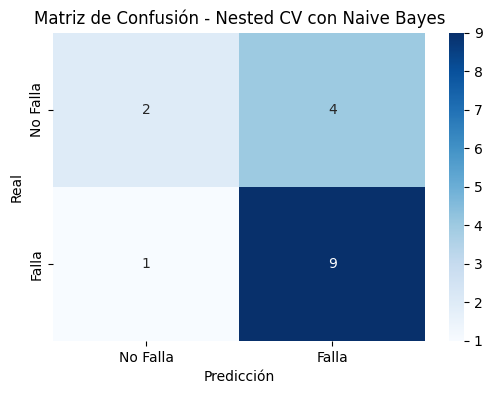

In [76]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con Naive Bayes")
plt.show()


En el siguiente bloque de código se presentan los resultados obtenidos tras la ejecución del modelo, incluyendo las métricas de evaluación correspondientes.

In [77]:
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.69      0.90      0.78        10

    accuracy                           0.69        16
   macro avg       0.68      0.62      0.61        16
weighted avg       0.68      0.69      0.66        16



#### Curva ROC y AUC

AUC Score: 0.5833


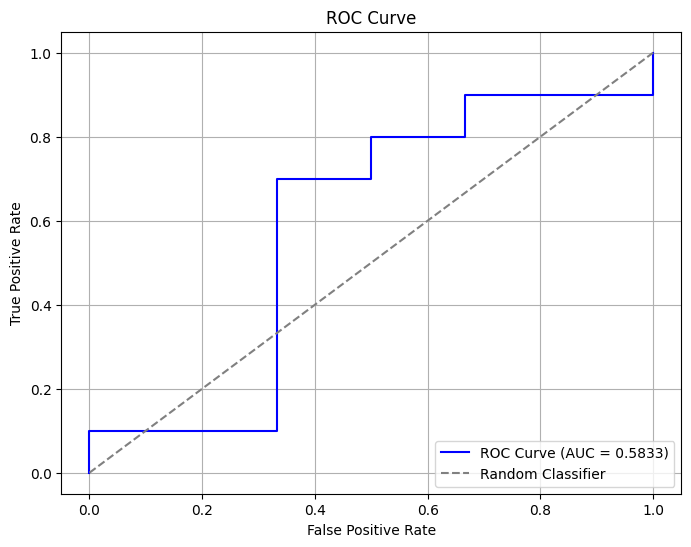

In [78]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Implementando Partial_fit()

A continuación, se presenta el código que implementa el algoritmo utilizando el método *partial_fit()*.

In [79]:
param_grid1 = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Controla la suavización para evitar valores extremos


cv_outer2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_inner2 = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)


# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []
processing_times = []

# Bucle externo (Nested CV Outer Loop)
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer2.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    
    # Datos de entrenamiento y prueba en este fold
    X_train_outer, X_test = X_train_inner.iloc[train_idx], X_train_inner.iloc[test_idx]
    y_train_outer, y_test = y_train_inner.iloc[train_idx], y_train_inner.iloc[test_idx]
    
    best_score = -np.inf
    best_param = None

    # Bucle interno (Nested CV Inner Loop)
    for var_smoothing in param_grid1:
        inner_scores = []

        for inner_train_idx, inner_val_idx in cv_inner2.split(X_train_outer, y_train_outer):
            X_train_inner_fold = X_train_outer.iloc[inner_train_idx]
            y_train_inner_fold = y_train_outer.iloc[inner_train_idx]
            X_val_fold = X_train_outer.iloc[inner_val_idx]
            y_val_fold = y_train_outer.iloc[inner_val_idx]

            # Entrenamiento
            model = GaussianNB(var_smoothing=var_smoothing)
            model.fit(X_train_inner_fold, y_train_inner_fold)

            # Predicción y evaluación
            y_val_pred = model.predict(X_val_fold)
            recall = recall_score(y_val_fold, y_val_pred)
            inner_scores.append(recall)

        avg_score = np.mean(inner_scores)

        if avg_score > best_score:
            best_score = avg_score
            best_param = var_smoothing

    # Entrenar modelo final sobre todo X_train_outer con mejor hiperparámetro
    final_model = GaussianNB(var_smoothing=best_param)
    final_model.fit(X_train_outer, y_train_outer)

    # Predicción en el test externo de este fold
    y_pred = final_model.predict(X_test)
    y_scores = final_model.predict_proba(X_test)[:, 1]

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(best_score)
    best_params_list.append(best_param)

    # Tiempo por fold
    end_time = time.time()
    processing_times.append(end_time - start_time)
    print(f"⏳ Fold {fold_idx}: terminado en {end_time - start_time:.2f} segundos")

⏳ Fold 1: terminado en 0.02 segundos
⏳ Fold 2: terminado en 0.02 segundos
⏳ Fold 3: terminado en 0.02 segundos


In [80]:
#  Hiperparámetro más frecuente
best_overall_param = Counter(best_params_list).most_common(1)[0][0]
print("Mejor valor global para 'var_smoothing':", best_overall_param)

# ⏱️ Tiempo promedio por cada valor de 'var_smoothing'
print("Tiempo promedio (basado en score) por valor de 'var_smoothing':")
for smoothing, scores in algorithm_times.items():
    avg_score = sum(scores) / len(scores)
    print(f"🔧 var_smoothing={smoothing}: promedio de recall interna = {avg_score:.4f} en {len(scores)} ejecuciones")


Mejor valor global para 'var_smoothing': 1e-09
Tiempo promedio (basado en score) por valor de 'var_smoothing':
🔧 var_smoothing=1e-09: promedio de recall interna = 0.0024 en 5 ejecuciones
🔧 var_smoothing=1e-08: promedio de recall interna = 0.0018 en 5 ejecuciones
🔧 var_smoothing=1e-07: promedio de recall interna = 0.0020 en 5 ejecuciones
🔧 var_smoothing=1e-06: promedio de recall interna = 0.0022 en 5 ejecuciones
🔧 var_smoothing=1e-05: promedio de recall interna = 0.0019 en 5 ejecuciones


Observamos que a pesar de que *partial_fit* sea un algortimo de optimizacion, obtenemos mejores tiempos de computo aplicando *GridsearchCV*

#### Evaluación del Modelo

In [81]:
# Después de evaluar KNN
resultados = train_and_evaluate_final_model(pipe, param_grid, X_train_inner, y_train_inner, X_test_ext, y_test_ext)

# Mostrar bonito
presentar_resultados(resultados)

# Guardar en la tabla de resultados
resultados_test_df = agregar_resultados_test("Clasificador Bayesiano", resultados, resultados_test_df)

# Ver la tabla actual
display(resultados_test_df)

🎯 Mejores Hiperparámetros Encontrados:
 - gaussiannb__var_smoothing: 1e-09

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.3333

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.04 segundos


,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858


## Modelo  L1/L2 Penalty Logistic Regression

En las siguientes líneas de código se implementará el modelo de Logistic Regression utilizando penalización L1 y L2. Se probarán ambos métodos de regularización con el objetivo de comparar su desempeño y determinar cuál se adapta mejor a los datos.

#### Entrenamiento del modelo

In [82]:
from sklearn.linear_model import LogisticRegression

# Crear pipeline con escalado y L1/L2 Penalty Logistic Regression
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,random_state=42))

# Definir hiperparámetros para GridSearch
param_grid = {
    "logisticregression__penalty": ["l1", "l2"],
    "logisticregression__C": [0.5,1,10],
    "logisticregression__solver": ["liblinear", "saga"]
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
                 # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["logisticregression__solver"]
        algorithm_times[algorithm].append(mean_time)
        


⏳ Tiempo total del fold 1: 0.06 segundos
⏳ Tiempo total del fold 2: 0.04 segundos
⏳ Tiempo total del fold 3: 0.04 segundos
⏳ Tiempo total del fold 4: 0.04 segundos
⏳ Tiempo total del fold 5: 0.05 segundos


A continuación, se compararán los tiempos de ejecución del modelo con y sin la aplicación de un algoritmo de optimización, con el fin de evaluar el impacto en el rendimiento computacional.

In [83]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"Smoothing '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("logisticregression__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
Smoothing 'liblinear': 0.0024 segundos (promedio en 30 ejecuciones)
Smoothing 'saga': 0.0026 segundos (promedio en 30 ejecuciones)
Mejores hiperparámetros globales: {'solver': 'liblinear', 'C': 0.5, 'penalty': 'l2'}


#### Matriz de Confusión y Métricas de Desempeño

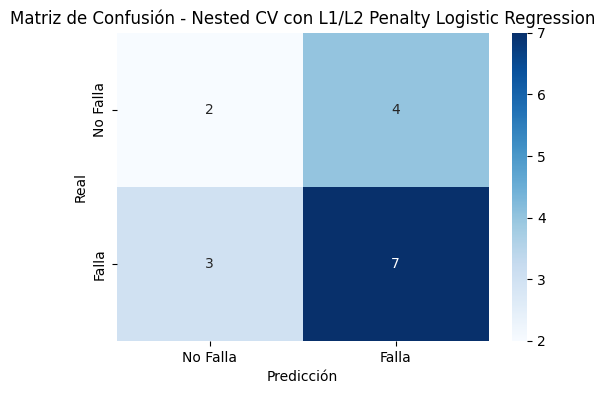

In [84]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con L1/L2 Penalty Logistic Regression")
plt.show()

In [85]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.8888888888888888, 0.611111111111111, 0.7777777777777777, 0.7222222222222222, 0.7222222222222222]
Mean Accuracy: 0.7444 ± 0.0903
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.40      0.33      0.36         6
           1       0.64      0.70      0.67        10

    accuracy                           0.56        16
   macro avg       0.52      0.52      0.52        16
weighted avg       0.55      0.56      0.55        16



#### Curva ROC y AUC

AUC Score: 0.5833


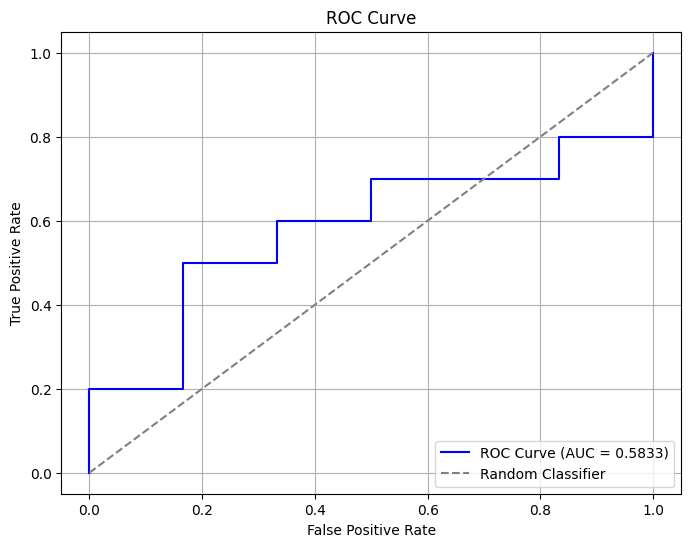

In [86]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

In [87]:
# Después de evaluar KNN
resultados = train_and_evaluate_final_model(pipe, param_grid, X_train_inner, y_train_inner, X_test_ext, y_test_ext)

# Mostrar bonito
presentar_resultados(resultados)

# Guardar en la tabla de resultados
resultados_test_df = agregar_resultados_test("L1/L2 Logistic Regression", resultados, resultados_test_df)

# Ver la tabla actual
display(resultados_test_df)

🎯 Mejores Hiperparámetros Encontrados:
 - logisticregression__C: 0.5
 - logisticregression__penalty: l1
 - logisticregression__solver: saga

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.6667

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.06 segundos


,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858
2,L1/L2 Logistic Regression,1.0,0.333333,0.5,0.666667,0.058786


## Modelo Random Forest 

En las siguientes líneas de código se implementará el modelo de *Random Forest*.

#### Entrenamiento del modelo

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Crear pipeline con escalado y Random Forest
pipe = make_pipeline(StandardScaler(), RandomForestClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    "randomforestclassifier__n_estimators": [100, 200, 300],  # Número de árboles
    "randomforestclassifier__max_depth": [10, 20, None],  # Profundidad del árbol
    "randomforestclassifier__min_samples_split": [2, 3, 4,5],  # Mínimos datos para dividir un nodo
    "randomforestclassifier__min_samples_leaf": [1, 2,3]  # Mínimos datos en una hoja
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["randomforestclassifier__n_estimators"]
        algorithm_times[algorithm].append(mean_time)

⏳ Tiempo total del fold 1: 5.08 segundos
⏳ Tiempo total del fold 2: 5.73 segundos
⏳ Tiempo total del fold 3: 5.35 segundos
⏳ Tiempo total del fold 4: 5.49 segundos
⏳ Tiempo total del fold 5: 5.66 segundos


In [89]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("randomforestclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 '100': 0.0626 segundos (promedio en 180 ejecuciones)
🔧 '200': 0.1226 segundos (promedio en 180 ejecuciones)
🔧 '300': 0.1811 segundos (promedio en 180 ejecuciones)
Mejores hiperparámetros globales: {'min_samples_split': 3, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 10}


#### Matriz de Confusión y Métricas de Desempeño

Nested CV Scores:  [0.6666666666666666, 0.5, 0.6666666666666666, 0.4444444444444444, 0.7777777777777777]
Mean Accuracy: 0.6111 ± 0.1217


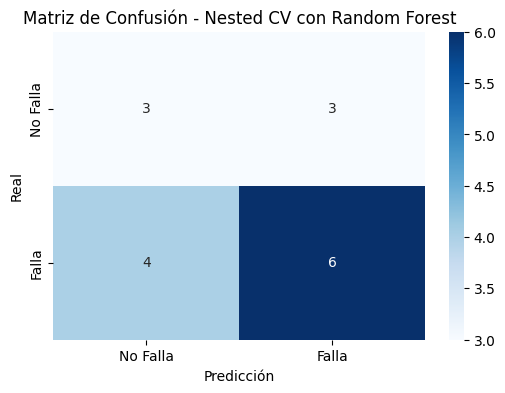

In [90]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))

# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con Random Forest")
plt.show()

In [91]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.6666666666666666, 0.5, 0.6666666666666666, 0.4444444444444444, 0.7777777777777777]
Mean Accuracy: 0.6111 ± 0.1217
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.67      0.60      0.63        10

    accuracy                           0.56        16
   macro avg       0.55      0.55      0.55        16
weighted avg       0.58      0.56      0.57        16



#### Curva ROC y AUC

AUC Score: 0.4500


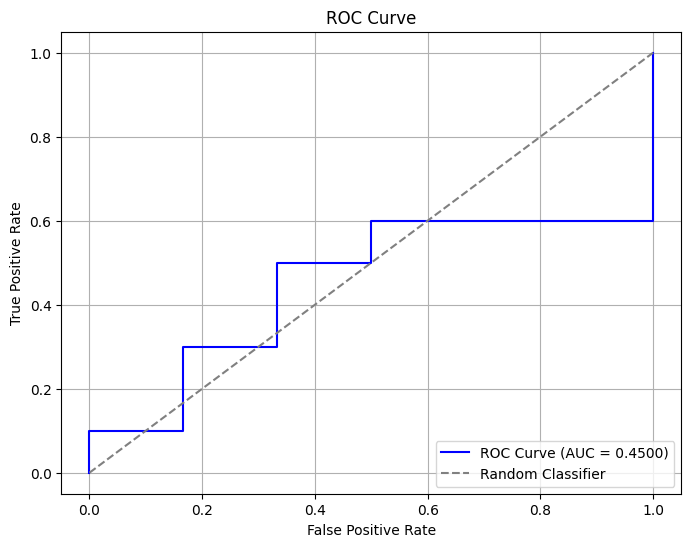

In [92]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

In [93]:
resultados = train_and_evaluate_final_model(pipe, param_grid, X_train_inner, y_train_inner, X_test_ext, y_test_ext)
presentar_resultados(resultados)
resultados_test_df = agregar_resultados_test("Random Forest", resultados, resultados_test_df)
display(resultados_test_df)


🎯 Mejores Hiperparámetros Encontrados:
 - randomforestclassifier__max_depth: 20
 - randomforestclassifier__min_samples_leaf: 3
 - randomforestclassifier__min_samples_split: 3
 - randomforestclassifier__n_estimators: 300

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.8333

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 5.77 segundos


,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858
2,L1/L2 Logistic Regression,1.0,0.333333,0.5,0.666667,0.058786
3,Random Forest,1.0,0.333333,0.5,0.833333,5.765745


## Modelo XGBoost

En las siguientes líneas de código se implementará el modelo de **XGBoost*, utilizando el método de construcción de árboles tipo *"hist" (Histogram-based)*, con el objetivo de optimizar el rendimiento y la velocidad de entrenamiento del modelo.

#### Entrenamiento del modelo - Tree method Hist()

In [94]:
from xgboost import XGBClassifier  # Para clasificación

# Crear pipeline con escalado y XGBoost
pipe = make_pipeline(StandardScaler(), XGBClassifier())

# Definir hiperparámetros para GridSearch
param_grid = {
    'xgbclassifier__n_estimators': [100, 200,300,400],  
    'xgbclassifier__max_depth': [3, 6, 9,10],  
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2,0.5],  
    'xgbclassifier__colsample_bytree': [0.5, 0.8, 1.0],
    'xgbclassifier__tree_method': ['hist', 'exact',None]   #Se realiza la prueba tambien sin modelo de optimizacion
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
processing_times = []
best_params_list2 = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list2.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
             # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["xgbclassifier__tree_method"]
        algorithm_times[algorithm].append(mean_time)
        

⏳ Tiempo total del fold 1: 3.82 segundos
⏳ Tiempo total del fold 2: 4.01 segundos
⏳ Tiempo total del fold 3: 3.86 segundos
⏳ Tiempo total del fold 4: 3.92 segundos
⏳ Tiempo total del fold 5: 3.71 segundos


In [95]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params12 = Counter(best_params_list2).most_common(1)[0][0]
best_overall_params12 = dict(best_overall_params12)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params1 = {k.replace("xgbclassifierr__", ""): v for k, v in best_overall_params12.items()}

print("Mejores hiperparámetros globales:", best_params1)


📊 Tiempo promedio por tipo de algoritmo:
🔧 'hist': 0.0141 segundos (promedio en 960 ejecuciones)
🔧 'exact': 0.0141 segundos (promedio en 960 ejecuciones)
🔧 'None': 0.0140 segundos (promedio en 960 ejecuciones)
Mejores hiperparámetros globales: {'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100, 'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__tree_method': 'hist', 'xgbclassifier__colsample_bytree': 0.5}


#### Matriz de Confusión y Métricas de Desempeño

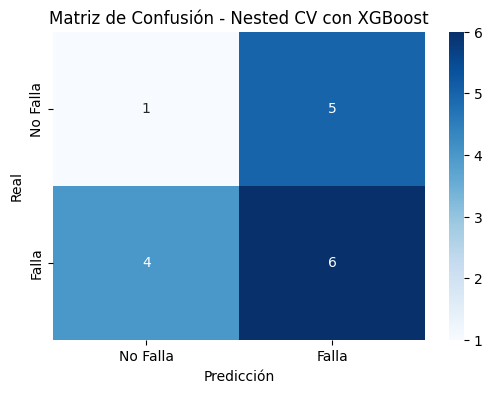

In [96]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con XGBoost")
plt.show()

In [97]:
# Mostrar resultados de Nested Cross-Validation
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Métricas adicionales
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7777777777777777, 0.16666666666666666, 0.6666666666666666, 0.38888888888888884, 0.6666666666666666]
Mean Accuracy: 0.5333 ± 0.2239
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.20      0.17      0.18         6
           1       0.55      0.60      0.57        10

    accuracy                           0.44        16
   macro avg       0.37      0.38      0.38        16
weighted avg       0.42      0.44      0.43        16



#### Curva ROC y AUC

AUC Score: 0.5083


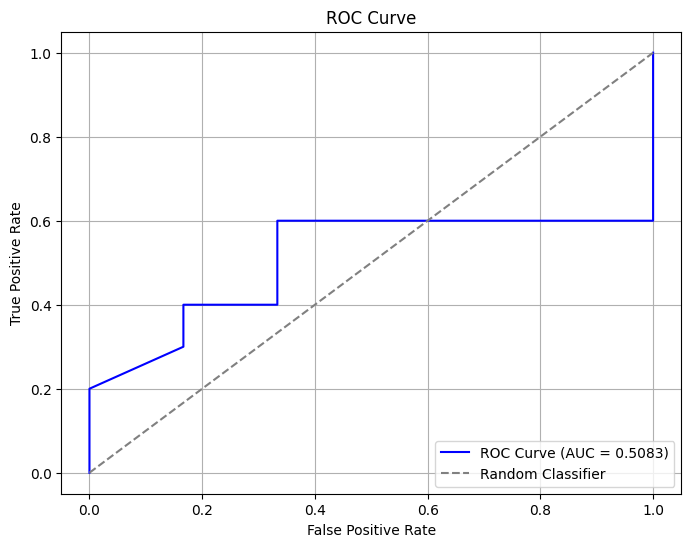

In [98]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

Para mejor lectura de los mejores parametros del modelo XGBoost, realizaremos una transformacion al objeto que contiene los mejores hiperparametros. 

In [99]:
def convertir_a_param_grid(params_dict):
    """
    Convierte un diccionario simple de hiperparámetros a formato válido para GridSearchCV.
    Cada valor será convertido a lista si no lo es.
    """
    new_grid = {}
    for key, value in params_dict.items():
        if isinstance(value, list):
            new_grid[key] = value
        else:
            new_grid[key] = [value]
    return new_grid


param_grid_xgb = convertir_a_param_grid(best_overall_params12)

In [100]:
pipe10 = make_pipeline(StandardScaler(),XGBClassifier() )

resultados = train_and_evaluate_final_model(pipe10, param_grid_xgb, X_train_inner, y_train_inner, X_test_ext, y_test_ext)
presentar_resultados(resultados)
resultados_test_df = agregar_resultados_test("XGBoost", resultados, resultados_test_df)
display(resultados_test_df)

🎯 Mejores Hiperparámetros Encontrados:
 - xgbclassifier__colsample_bytree: 0.5
 - xgbclassifier__learning_rate: 0.01
 - xgbclassifier__max_depth: 3
 - xgbclassifier__n_estimators: 100
 - xgbclassifier__tree_method: hist

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.8333

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.666667,1.000000,0.8,2.0
1,1.000000,0.666667,0.8,3.0
accuracy,0.800000,0.800000,0.8,0.8
macro avg,0.833333,0.833333,0.8,5.0
weighted avg,0.866667,0.800000,0.8,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,1,2



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.14 segundos


,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858
2,L1/L2 Logistic Regression,1.0,0.333333,0.5,0.666667,0.058786
3,Random Forest,1.0,0.333333,0.5,0.833333,5.765745
4,XGBoost,1.0,0.666667,0.8,0.833333,0.139804


## Modelo SVM (Support Vector Machines)

En las siguientes líneas de código se implementará el modelo de **Máquinas de Vectores de Soporte (SVM)** utilizando distintos tipos de *kernels*

#### Entrenamiento del modelo

In [101]:
from sklearn.svm import SVC

# Crear pipeline con escalado y SVM
pipe = Pipeline([
    ('standardscaler', StandardScaler()),
    ('svc', SVC(probability=True))  
])

# Definir hiperparámetros para GridSearch
param_grid = {'svc__C': [0.001, 0.01, 0.1, 1, 10, 1000,0.0001], 
              'svc__gamma': [0.001, 0.01, 0.1, 1, 10, 100,0.0001],
              'svc__kernel': ['linear', 'rbf', 'poly', 'sigmoid']
              }

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
    # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["svc__kernel"]
        algorithm_times[algorithm].append(mean_time)


⏳ Tiempo total del fold 1: 0.40 segundos
⏳ Tiempo total del fold 2: 0.39 segundos
⏳ Tiempo total del fold 3: 0.35 segundos
⏳ Tiempo total del fold 4: 0.32 segundos
⏳ Tiempo total del fold 5: 0.35 segundos


In [102]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos 
best_params = {k.replace("svc__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)



📊 Tiempo promedio por tipo de algoritmo:
🔧 'linear': 0.0027 segundos (promedio en 245 ejecuciones)
🔧 'rbf': 0.0026 segundos (promedio en 245 ejecuciones)
🔧 'poly': 0.0024 segundos (promedio en 245 ejecuciones)
🔧 'sigmoid': 0.0026 segundos (promedio en 245 ejecuciones)
Mejores hiperparámetros globales: {'C': 10, 'kernel': 'rbf', 'gamma': 0.01}


#### Matriz de Confusión y Métricas de Desempeño

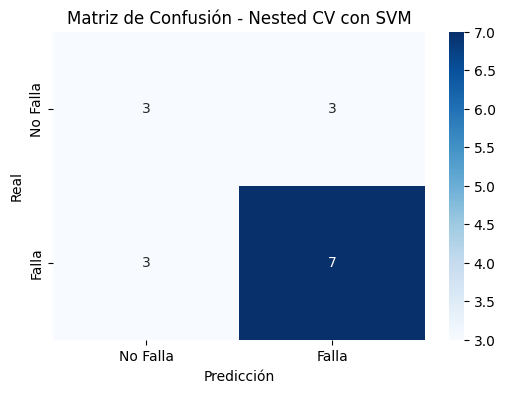

In [103]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con SVM")
plt.show()

In [104]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.9333333333333332, 0.9444444444444445, 0.888888888888889, 0.8111111111111112, 0.85]
Mean Accuracy: 0.8856 ± 0.0501
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.70      0.70      0.70        10

    accuracy                           0.62        16
   macro avg       0.60      0.60      0.60        16
weighted avg       0.62      0.62      0.62        16



#### Curva ROC y AUC

AUC Score: 0.6500


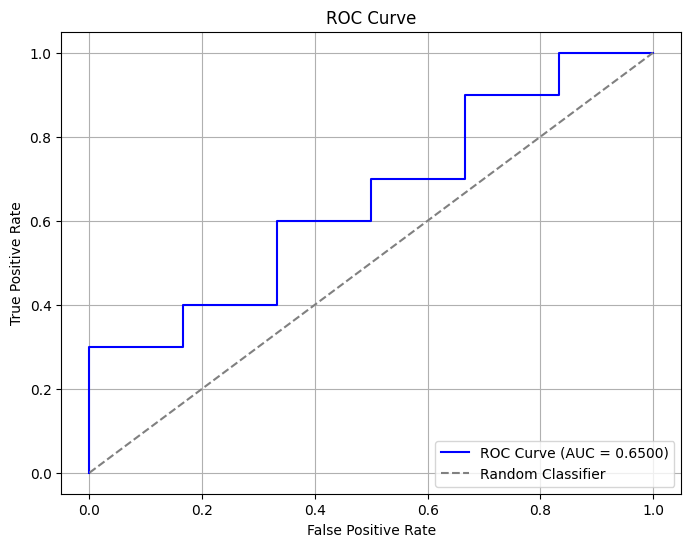

In [105]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

In [106]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

# 1. Definir Pipeline
pipe3 = make_pipeline(
    StandardScaler(),
    SVC(probability=True, C=1.0, kernel='rbf', gamma='scale', random_state=42)  # Puedes ajustar parámetros aquí si quieres
)

# 2. Entrenar el modelo completo
pipe3.fit(X_train_inner, y_train_inner)

# 3. Predecir sobre el Test externo
y_pred_svm = pipe3.predict(X_test_ext)
y_proba_svm = pipe3.predict_proba(X_test_ext)[:, 1]

# 4. Evaluar métricas
report_svm = classification_report(y_test_ext, y_pred_svm, output_dict=True)
roc_auc_svm = roc_auc_score(y_test_ext, y_proba_svm)
matrix_svm = confusion_matrix(y_test_ext, y_pred_svm)

# 5. Mostrar resultados bonito
print("🎯 Mejores Hiperparámetros usados en SVM:")
print(" - C=1.0")
print(" - kernel='rbf'")
print(" - gamma='scale'")
print("\n📈 ROC AUC Score en Test Externo:")
print(f" - ROC AUC: {roc_auc_svm:.4f}")

print("\n📝 Reporte de Clasificación:")
report_df_svm = pd.DataFrame(report_svm).transpose()
display(report_df_svm)

print("\n🧩 Matriz de Confusión:")
matrix_df_svm = pd.DataFrame(matrix_svm, index=["Actual 0", "Actual 1"], columns=["Predicho 0", "Predicho 1"])
display(matrix_df_svm)

# 6. Agregar resultados al DataFrame de resumen
def agregar_resultados_test_manual(nombre_modelo, report, auc, tiempo=0):
    """
    Agrega resultados manualmente a la tabla de test.
    """
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    
    nueva_fila = {
        "Modelo": nombre_modelo,
        "Precisión": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Tiempo (s)": tiempo
    }
    
    return pd.concat([resultados_test_df, pd.DataFrame([nueva_fila])], ignore_index=True)

# Guardarlo
resultados_test_df = agregar_resultados_test_manual("SVM", report_svm, roc_auc_svm)

# Mostrar tabla final actualizada
display(resultados_test_df)



🎯 Mejores Hiperparámetros usados en SVM:
 - C=1.0
 - kernel='rbf'
 - gamma='scale'

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 1.0000

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1


,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858
2,L1/L2 Logistic Regression,1.0,0.333333,0.5,0.666667,0.058786
3,Random Forest,1.0,0.333333,0.5,0.833333,5.765745
4,XGBoost,1.0,0.666667,0.8,0.833333,0.139804
5,SVM,1.0,0.333333,0.5,1.000000,0.000000


## Modelo ANN (Redes Neuronales Artificiales)

En las siguientes líneas de código se implementará el modelo de **Redes Neuronales** utilizando un *Perceptrón Multicapa (MLP)*. Se evaluarán los tiempos de optimización en función del número de capas ocultas, con el objetivo de analizar el impacto de esta configuración en el rendimiento del modelo.

In [107]:
from sklearn.neural_network import MLPClassifier

# Crear pipeline con escalado y MLP
pipe = make_pipeline(StandardScaler(),  MLPClassifier(random_state=42, max_iter=10000000000))

# Definir hiperparámetros para GridSearch
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(5,), (10,), (15,), (20,),(25,),(8,10,7)],  # Número de neuronas en las capas ocultas
    'mlpclassifier__activation': ['relu', 'tanh', 'logistic'],  # Función de activación
    'mlpclassifier__solver': ['adam', 'lbfgs'],  # Algoritmo de optimización
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01],  # Parámetro de regularización L2
    'mlpclassifier__learning_rate': ['constant', 'adaptive'],  # Estrategia de tasa de aprendizaje
}

# Variables para guardar resultados
all_y_true = []
all_y_pred = []
all_y_scores = []
nested_scores = []
best_params_list = []  # Guardamos los mejores hiperparámetros en cada iteración
processing_times = []

# Diccionario para tiempos por tipo de algoritmo
algorithm_times = defaultdict(list)

# Iterar sobre los folds de la validación externa
# Iterar sobre los folds de la validación externa
for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_train_inner, y_train_inner), 1):
    start_time = time.time()
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Antes de SMOTE
    counter = Counter(y_train)
    minority_class_count = min(counter.values())

    # Ajustar k_neighbors para SMOTE
    k_neighbors = min(5, minority_class_count - 1)  # 5 por defecto, pero ajustable

    # Aplicar SMOTE a los datos de entrenamiento
    smote = SMOTE(random_state=42, k_neighbors= k_neighbors)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Aplicar GridSearchCV dentro de cada fold
    grid_search = GridSearchCV(pipe, param_grid, cv=cv_inner, scoring="recall", n_jobs=-1)
    grid_search.fit(X_train_res, y_train_res)  

    # Guardar los mejores hiperparámetros de esta iteración
    best_params_list.append(frozenset(grid_search.best_params_.items()))

    # Obtener el mejor modelo y hacer predicciones en el conjunto de prueba
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_scores = best_model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

    # Guardar resultados
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_scores.extend(y_scores)
    nested_scores.append(grid_search.best_score_)
    
    # Guardar tiempo por fold
    end_time = time.time()
    elapsed_time = end_time - start_time
    processing_times.append(elapsed_time)
    print(f"⏳ Tiempo total del fold {fold_idx}: {elapsed_time:.2f} segundos")

    # Medir tiempo promedio por tipo de algoritmo en GridSearch interna
    results = grid_search.cv_results_
    for mean_time, params in zip(results["mean_fit_time"], results["params"]):
        algorithm = params["mlpclassifier__hidden_layer_sizes"]
        algorithm_times[algorithm].append(mean_time)




⏳ Tiempo total del fold 1: 4.32 segundos
⏳ Tiempo total del fold 2: 4.45 segundos
⏳ Tiempo total del fold 3: 4.52 segundos
⏳ Tiempo total del fold 4: 4.68 segundos
⏳ Tiempo total del fold 5: 4.62 segundos


In [108]:
# Encontrar los hiperparámetros más frecuentes
best_overall_params = Counter(best_params_list).most_common(1)[0][0]
best_overall_params = dict(best_overall_params)  # Convertimos de nuevo a diccionario

# Tiempo promedio por tipo de algoritmo
print("\n📊 Tiempo promedio por tipo de algoritmo:")
for algorithm, times in algorithm_times.items():
    avg_time = sum(times) / len(times)
    print(f"🔧 '{algorithm}': {avg_time:.4f} segundos (promedio en {len(times)} ejecuciones)")

# Eliminamos los prefijos
best_params = {k.replace("mlpclassifier__", ""): v for k, v in best_overall_params.items()}

print("Mejores hiperparámetros globales:", best_params)


📊 Tiempo promedio por tipo de algoritmo:
🔧 '(5,)': 0.0747 segundos (promedio en 180 ejecuciones)
🔧 '(10,)': 0.0516 segundos (promedio en 180 ejecuciones)
🔧 '(15,)': 0.0463 segundos (promedio en 180 ejecuciones)
🔧 '(20,)': 0.0445 segundos (promedio en 180 ejecuciones)
🔧 '(25,)': 0.0390 segundos (promedio en 180 ejecuciones)
🔧 '(8, 10, 7)': 0.0505 segundos (promedio en 180 ejecuciones)
Mejores hiperparámetros globales: {'activation': 'relu', 'solver': 'adam', 'alpha': 0.0001, 'learning_rate': 'constant', 'hidden_layer_sizes': (15,)}


In [109]:
best_overall_params

{'mlpclassifier__activation': 'relu',
 'mlpclassifier__solver': 'adam',
 'mlpclassifier__alpha': 0.0001,
 'mlpclassifier__learning_rate': 'constant',
 'mlpclassifier__hidden_layer_sizes': (15,)}

#### Matriz de Confusión y Métricas de Desempeño

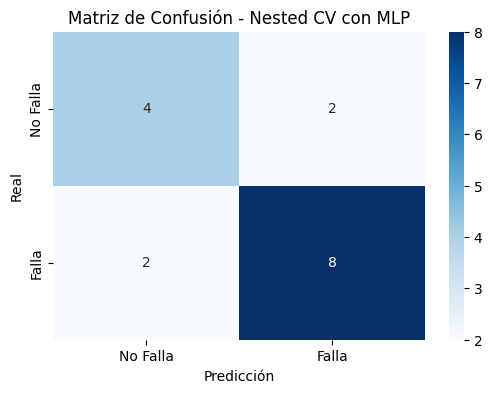

In [110]:
# Matriz de Confusión
conf_matrix = confusion_matrix(all_y_true, all_y_pred)

# Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Falla", "Falla"], yticklabels=["No Falla", "Falla"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Nested CV con MLP")
plt.show()

In [111]:
# Evaluación final
print("Nested CV Scores: ", nested_scores)
print("Mean Accuracy: {:.4f} ± {:.4f}".format(np.mean(nested_scores), np.std(nested_scores)))
# Reporte de clasificación
print("Reporte de clasificación:\n", classification_report(all_y_true, all_y_pred))

Nested CV Scores:  [0.7777777777777777, 1.0, 1.0, 0.7777777777777778, 0.8888888888888888]
Mean Accuracy: 0.8889 ± 0.0994
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         6
           1       0.80      0.80      0.80        10

    accuracy                           0.75        16
   macro avg       0.73      0.73      0.73        16
weighted avg       0.75      0.75      0.75        16



#### Curva ROC y AUC

AUC Score: 0.7667


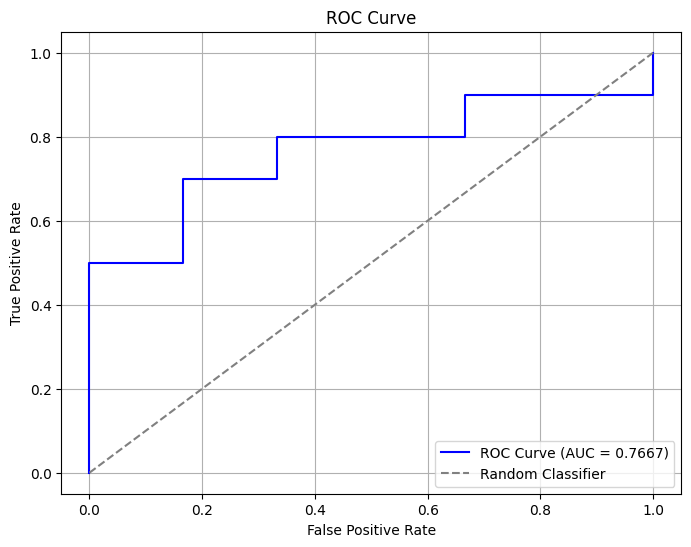

In [112]:
# Calcular AUC
auc_score = roc_auc_score(all_y_true, all_y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Calcular puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_scores)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

In [113]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignorar solo los ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


pipe9 = make_pipeline(StandardScaler(), MLPClassifier(max_iter=10000000000))
param_grid_mlp = convertir_a_param_grid(best_overall_params)

resultados = train_and_evaluate_final_model(pipe9, param_grid_mlp, X_train_inner, y_train_inner, X_test_ext, y_test_ext)
presentar_resultados(resultados)
resultados_test_df = agregar_resultados_test("MLP", resultados, resultados_test_df)


🎯 Mejores Hiperparámetros Encontrados:
 - mlpclassifier__activation: relu
 - mlpclassifier__alpha: 0.0001
 - mlpclassifier__hidden_layer_sizes: (15,)
 - mlpclassifier__learning_rate: constant
 - mlpclassifier__solver: adam

📈 ROC AUC Score en Test Externo:
 - ROC AUC: 0.5000

📝 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.50,1.000000,0.666667,2.0
1,1.00,0.333333,0.500000,3.0
accuracy,0.60,0.600000,0.600000,0.6
macro avg,0.75,0.666667,0.583333,5.0
weighted avg,0.80,0.600000,0.566667,5.0



🧩 Matriz de Confusión:


,Predicho 0,Predicho 1
Actual 0,2,0
Actual 1,2,1



⏳ Tiempo Total de Entrenamiento y Evaluación:
 - 0.17 segundos


### Resultados 

A continuación, se presentan los resultados obtenidos por todos los modelos evaluados a lo largo de los training y testing.

#### Training

In [114]:
# Lista de modelos
modelos = [
    "KNN",
    "Naive Bayes",
    "LogReg (L2)",
    "Random Forest",
    "XGBoost",
    "SVM",
    "ANN MLP"
]

# Inicializamos el DataFrame
metricas = ["Precision", "Recall", "F1-score", "Accuracy", "AUC"]
tabla_resultados = pd.DataFrame(index=modelos, columns=metricas)

# Ejemplo: llenado de una fila (cuando tengas resultados)
tabla_resultados.loc["KNN"] = [0.86, 0.60, 0.71, 0.69, 0.77]
tabla_resultados.loc["Naive Bayes"] = [0.69, 0.90, 0.78, 0.69, 0.58]
tabla_resultados.loc["LogReg (L2)"] = [0.64, 0.70, 0.67, 0.56, 0.58]
tabla_resultados.loc["Random Forest"] = [0.67, 0.60, 0.63, 0.56, 0.48]
tabla_resultados.loc["XGBoost"] = [0.55, 0.60, 0.57, 0.44, 0.50]
tabla_resultados.loc["SVM"] = [0.70, 0.70, 0.70, 0.62, 0.6]
tabla_resultados.loc["ANN MLP"] = [0.80, 0.80, 0.80, 0.75, 0.76]

display(tabla_resultados)

,Precision,Recall,F1-score,Accuracy,AUC
KNN,0.86,0.6,0.71,0.69,0.77
Naive Bayes,0.69,0.9,0.78,0.69,0.58
LogReg (L2),0.64,0.7,0.67,0.56,0.58
Random Forest,0.67,0.6,0.63,0.56,0.48
XGBoost,0.55,0.6,0.57,0.44,0.5
SVM,0.7,0.7,0.7,0.62,0.6
ANN MLP,0.8,0.8,0.8,0.75,0.76


En la tabla anterior se muestra el desempeño de todos los modelos base según cada una de las métricas de evaluación. Al considerar el recall como la métrica principal, se observa que ninguno de los modelos cumple con las expectativas para la predicción de fallas.

#### Testing

In [115]:
display(resultados_test_df)

,Modelo,Precisión,Recall,F1-Score,ROC AUC,Tiempo (s)
0,KNN,1.0,0.333333,0.5,1.000000,0.064823
1,Clasificador Bayesiano,1.0,0.333333,0.5,0.333333,0.042858
2,L1/L2 Logistic Regression,1.0,0.333333,0.5,0.666667,0.058786
3,Random Forest,1.0,0.333333,0.5,0.833333,5.765745
4,XGBoost,1.0,0.666667,0.8,0.833333,0.139804
5,SVM,1.0,0.333333,0.5,1.000000,0.000000
6,MLP,1.0,0.333333,0.5,0.500000,0.165458
